In [88]:
from sklearn.linear_model import LogisticRegression

X = [[10000],[20000],[15000],[30000],[2000]]
y = [0, 1, 0, 1, 1]
model = LogisticRegression()
model.fit(X, y)

print(model.predict([[5000]])) 

[0]


In [89]:
#understand the data 
import pandas as pd
import numpy as np

df = pd.read_csv("Loan dataset_classification.csv")
df.head()
df.info()
df.columns
df.describe()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64

Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64


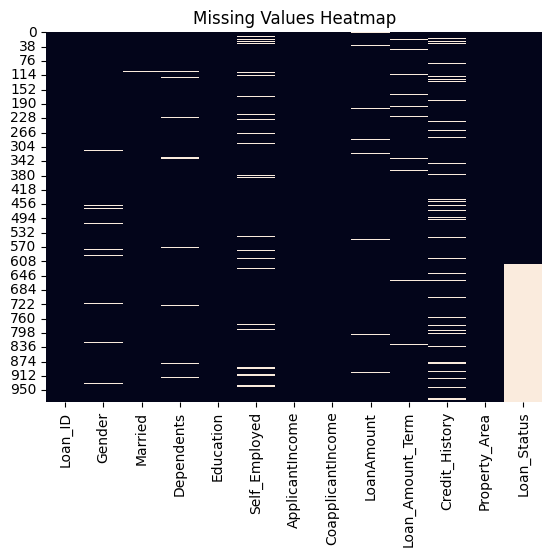

In [90]:
#list missing values
missing_values = df.isnull().sum() 
print(missing_values)
#visualize missing values 
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [91]:
#fill missing values of married column with mode
mode_married = df['Married'].mode()[0]
df['Married'].fillna(mode_married, inplace=True)
#display updated missing values
print(df['Married'].isnull().sum())
#


0


<Axes: xlabel='Loan_Status'>

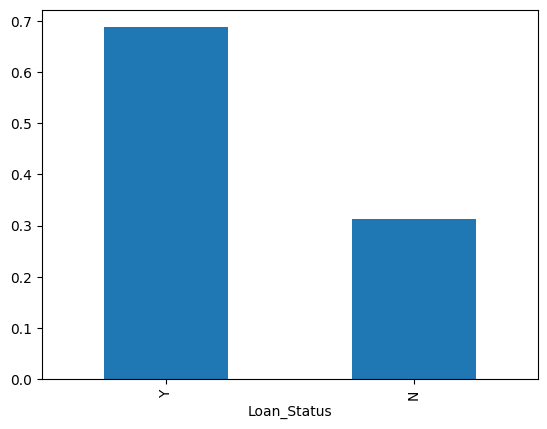

In [92]:
#check how many loan status are there
df['Loan_Status'].value_counts()
df['Loan_Status'].value_counts(normalize=True)*100
df['Loan_Status'].value_counts(normalize=True).plot.bar()

<Axes: >

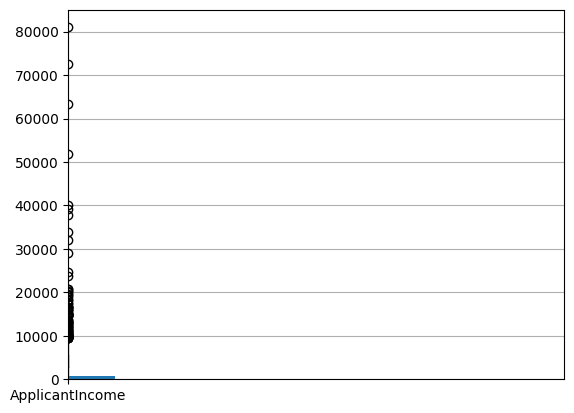

In [93]:
df['ApplicantIncome'].hist()
df.boxplot(column='ApplicantIncome')

<Axes: >

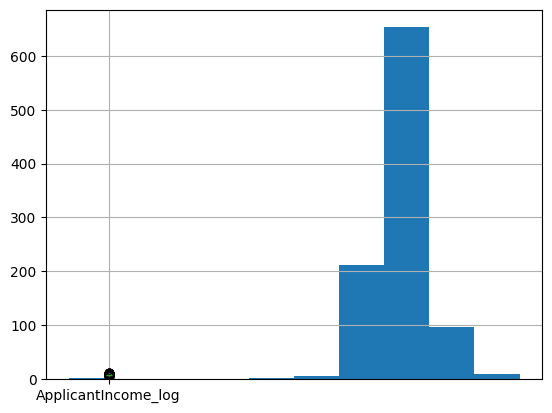

In [94]:
#income is right skewed, so we apply log transformation
import numpy as np  
df['ApplicantIncome_log'] = np.log(df['ApplicantIncome']+1)
df['ApplicantIncome_log'].hist()
df.boxplot(column='ApplicantIncome_log')


<Axes: >

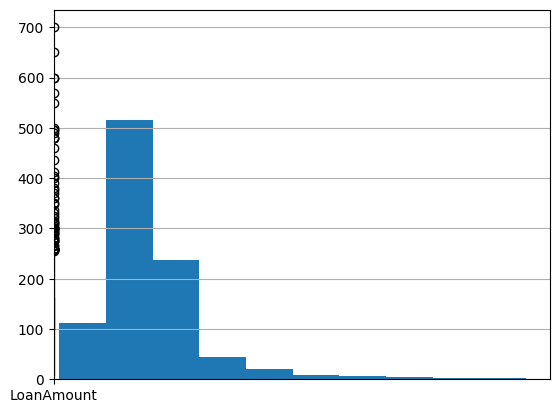

In [95]:
#histogram and box plot for loan amount

df['LoanAmount'].hist()
df.boxplot(column='LoanAmount') 


In [96]:
#bivariate analysis

pd.crosstab(df['Married'], df['Loan_Status'])
#percentage
pd.crosstab(df['Married'], df['Loan_Status'], normalize='index') * 100

Loan_Status,N,Y
Married,,
No,37.089202,62.910798
Yes,28.179551,71.820449


In [97]:
display(pd.crosstab(df['Education'], df['Loan_Status']))

Loan_Status,N,Y
Education,,
Graduate,140,340
Not Graduate,52,82


In [98]:
#define categorical columns
categorical_cols = ['Married', 'Education', 'Self_Employed', 'Property_Area']
for col in categorical_cols:
    print(f"\nPercentage Crosstab for {col} vs Loan_Status\n")
    print(pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100)


Percentage Crosstab for Married vs Loan_Status

Loan_Status          N          Y
Married                          
No           37.089202  62.910798
Yes          28.179551  71.820449

Percentage Crosstab for Education vs Loan_Status

Loan_Status           N          Y
Education                         
Graduate      29.166667  70.833333
Not Graduate  38.805970  61.194030

Percentage Crosstab for Self_Employed vs Loan_Status

Loan_Status            N          Y
Self_Employed                      
No             31.400000  68.600000
Yes            31.707317  68.292683

Percentage Crosstab for Property_Area vs Loan_Status

Loan_Status            N          Y
Property_Area                      
Rural          38.547486  61.452514
Semiurban      23.175966  76.824034
Urban          34.158416  65.841584


In [99]:
# Separate numerical and categorical columns
num_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

cat_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Credit_History',
    'Property_Area'
]

# Fill numerical columns with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values
df.isnull().sum()


Loan_ID                  0
Gender                   0
Married                  0
Dependents               0
Education                0
Self_Employed            0
ApplicantIncome          0
CoapplicantIncome        0
LoanAmount               0
Loan_Amount_Term         0
Credit_History           0
Property_Area            0
Loan_Status            367
ApplicantIncome_log      0
dtype: int64

In [100]:
df['Dependents'] = df['Dependents'].replace('3+', '3')

In [101]:
# Manual mapping
# Map columns to numeric
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Credit_History'] = df['Credit_History'].map({1.0: 1, 0.0: 0})
df['Property_Area'] = df['Property_Area'].map({
    'Urban': 1,
    'Semiurban': 2,
    'Rural': 3
})


In [102]:
# Training data → Loan_Status is known
train_df = df[df['Loan_Status'].notnull()]

In [103]:

# Testing data → Loan_Status is unknown
test_df = df[df['Loan_Status'].isnull()]



In [104]:
# Check which columns still have missing values
print(X_train.isnull().sum())


Married               1
Education             0
Self_Employed        24
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     12
Credit_History       40
Property_Area         0
dtype: int64


In [105]:
# Fill categorical columns with mode
cat_cols = ['Married', 'Education', 'Self_Employed', 'Property_Area']
for col in cat_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)

# Verify no NaNs remain
print(train_df[cat_cols].isnull().sum())


Married          0
Education        0
Self_Employed    0
Property_Area    0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_6672\2425955769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[col].fillna(train_df[col].mode()[0], inplace=True)
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_6672\2425955769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[col].fillna(train_df[col].mode()[0], inplace=True)
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_6672\2425955769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

In [106]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import numpy as np

# Define feature columns
feature_cols = [
    'ApplicantIncome_log',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Dependents',
    'Married',
    'Education',
    'Self_Employed',
    'Credit_History',
    'Property_Area'
]

print("Preparing training data...")
# Prepare training data - only use rows with Loan_Status
train_mask = train_df['Loan_Status'].notnull()
print(f"Rows with Loan_Status: {train_mask.sum()}")

X_train = train_df.loc[train_mask, feature_cols].copy()
y_train = train_df.loc[train_mask, 'Loan_Status'].copy()

# Use SimpleImputer to fill all NaN values
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)

print(f"✓ Training data shape: {X_train.shape}")

# Prepare test data
X_test = test_df[feature_cols].copy()
X_test = imputer.transform(X_test)
print(f"✓ Test data shape: {X_test.shape}")

# Initialize and train Logistic Regression model
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_train = lr_model.predict(X_train)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"\n✓ Training Accuracy: {train_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train)
print(f"\n✓ Confusion Matrix:")
print(cm)

# Classification Report
print(f"\n✓ Classification Report:")
print(classification_report(y_train, y_pred_train, target_names=['Rejected (0)', 'Approved (1)']))

# Make predictions on test data
y_pred_test = lr_model.predict(X_test)
print(f"\n✓ Predictions on {len(y_pred_test)} test samples:")
print(f"  Approved (1): {sum(y_pred_test == 1)}")
print(f"  Rejected (0): {sum(y_pred_test == 0)}")
print(f"\nFirst 10 predictions: {y_pred_test[:10]}")

Preparing training data...
Rows with Loan_Status: 614
✓ Training data shape: (614, 10)
✓ Test data shape: (367, 10)

Training Logistic Regression...

✓ Training Accuracy: 0.8111

✓ Confusion Matrix:
[[ 84 108]
 [  8 414]]

✓ Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.91      0.44      0.59       192
Approved (1)       0.79      0.98      0.88       422

    accuracy                           0.81       614
   macro avg       0.85      0.71      0.73       614
weighted avg       0.83      0.81      0.79       614


✓ Predictions on 367 test samples:
  Approved (1): 0
  Rejected (0): 0

First 10 predictions: ['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y']


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [107]:
# Simple Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Create and train simple model
simple_model = LogisticRegression(max_iter=1000, random_state=42)
simple_model.fit(X_train, y_train)

# Make predictions
y_pred_simple = simple_model.predict(X_train)

# Calculate accuracy
simple_accuracy = accuracy_score(y_train, y_pred_simple)
print(f"Simple Logistic Regression Accuracy: {simple_accuracy:.4f}")

# Test predictions
y_pred_simple_test = simple_model.predict(X_test)
print(f"Test predictions (first 10): {y_pred_simple_test[:10]}")

Simple Logistic Regression Accuracy: 0.8111
Test predictions (first 10): ['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y']


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [108]:
# Loan dataset prdecition using Logistic Regression with Pipeline
##import statements

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [109]:
# reading the dataset and creating train and test data
df= pd.read_csv("Loan dataset_classification.csv")

df = df.dropna(subset=["Loan_Status"])

X = df.drop(columns=["Loan_Status","Loan_ID","Gender","Dependents"], axis=1)
y = df["Loan_Status"].map({"Y":1,"N":0})
print(y.shape)
print(y.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

(614,)
0


In [110]:
# deciding all the columns which are getting used for prediction

log_cols = ["ApplicantIncome", "CoapplicantIncome"] 
num_cols = [ "LoanAmount", "Credit_History","Loan_Amount_Term"]
cat_cols = [ "Married", "Self_Employed","Education","Property_Area"]


In [111]:
# Creating pipelines 
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [112]:
# Applying pipeline on the model dataset
preprocessor = ColumnTransformer([
    ("log_num", log_numeric_pipeline, log_cols),
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

model_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced"))
])

Accuracy: 0.7317073170731707


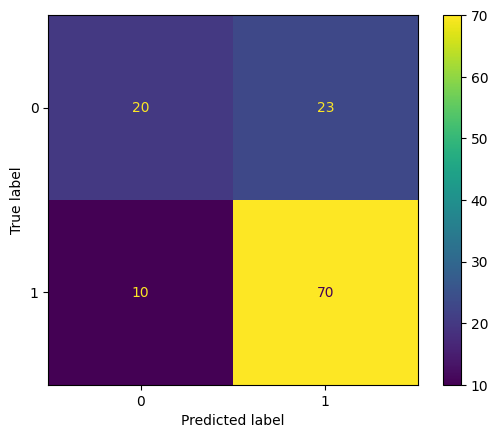

In [113]:
# training the model
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [114]:
# Test the model with new sample data
import pandas as pd

# Validation function for Credit History
def validate_credit_history_individual(credit_history_value):
    """Validate that Credit_History is either 0 or 1 and return status"""
    if credit_history_value in [0, 1, 0.0, 1.0]:
        return True, "PASS"
    else:
        return False, f"FAIL - Credit_History must be 0 or 1, but got {credit_history_value}"

# Create a new sample entry
new_applicant = pd.DataFrame({
    'ApplicantIncome': [50000],
    'CoapplicantIncome': [25000],
    'LoanAmount': [300],
    'Loan_Amount_Term': [360],
    'Credit_History': [1.0],
    'Married': ['Yes'],
    'Self_Employed': ['No'],
    'Education': ['Graduate'],
    'Property_Area': ['Urban']
})

print("=" * 60)
print("APPLICANT 1 - VALIDATION AND PREDICTION")
print("=" * 60)
print("\nApplicant Data:")
print(new_applicant)

# Validate Credit_History for applicant 1
is_valid1, status1 = validate_credit_history_individual(new_applicant['Credit_History'].values[0])
print(f"\nValidation Result: {status1}")

if is_valid1:
    # Make prediction only if validation passes
    prediction = model_pipeline.predict(new_applicant)
    prediction_proba = model_pipeline.predict_proba(new_applicant)
    
    print(f"\nPrediction: {'Loan Approved (Y)' if prediction[0] == 1 else 'Loan Rejected (N)'}")
    print(f"Confidence: {max(prediction_proba[0]) * 100:.2f}%")
    print(f"Probabilities - Rejected: {prediction_proba[0][0]:.4f}, Approved: {prediction_proba[0][1]:.4f}")
else:
    print("\n⚠️ Cannot make prediction - Validation failed!")

# Test with another applicant
print("\n" + "=" * 60)
print("APPLICANT 2 - VALIDATION AND PREDICTION")
print("=" * 60)

new_applicant2 = pd.DataFrame({
    'ApplicantIncome': [15000],
    'CoapplicantIncome': [5000],
    'LoanAmount': [100],
    'Loan_Amount_Term': [240],
    'Credit_History': [-3],
    'Married': ['No'],
    'Self_Employed': ['Yes'],
    'Education': ['Not Graduate'],
    'Property_Area': ['Rural']
})

print("\nApplicant Data:")
print(new_applicant2)

# Validate Credit_History for applicant 2
is_valid2, status2 = validate_credit_history_individual(new_applicant2['Credit_History'].values[0])
print(f"\nValidation Result: {status2}")

if is_valid2:
    # Make prediction only if validation passes
    prediction2 = model_pipeline.predict(new_applicant2)
    prediction_proba2 = model_pipeline.predict_proba(new_applicant2)
    
    print(f"\nPrediction: {'Loan Approved (Y)' if prediction2[0] == 1 else 'Loan Rejected (N)'}")
    print(f"Confidence: {max(prediction_proba2[0]) * 100:.2f}%")
    print(f"Probabilities - Rejected: {prediction_proba2[0][0]:.4f}, Approved: {prediction_proba2[0][1]:.4f}")
else:
    print("\n⚠️ Cannot make prediction - Validation failed!")

# Summary
print("\n" + "=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"Applicant 1 - Validation: {status1}")
print(f"Applicant 2 - Validation: {status2}")


APPLICANT 1 - VALIDATION AND PREDICTION

Applicant Data:
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0            50000              25000         300               360   

   Credit_History Married Self_Employed Education Property_Area  
0             1.0     Yes            No  Graduate         Urban  

Validation Result: PASS

Prediction: Loan Approved (Y)
Confidence: 80.32%
Probabilities - Rejected: 0.1968, Approved: 0.8032

APPLICANT 2 - VALIDATION AND PREDICTION

Applicant Data:
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0            15000               5000         100               240   

   Credit_History Married Self_Employed     Education Property_Area  
0              -3      No           Yes  Not Graduate         Rural  

Validation Result: FAIL - Credit_History must be 0 or 1, but got -3

⚠️ Cannot make prediction - Validation failed!

VALIDATION SUMMARY
Applicant 1 - Validation: PASS
Applicant 2 - Validation: FAIL - 

In [115]:
class CreditHistoryValidator(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if (0<X["Credit_History"] <3).any():
            raise ValueError("Credit_History should be between 0 to 3")
        if (X["ApplicantIncome"] < 0).any():
            raise ValueError("ApplicantIncome cannot be negative")
        return X


model_pipeline = Pipeline([
    ("credit_history_validation", CreditHistoryValidator()),
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced",max_iter=3000))
])


NameError: name 'BaseEstimator' is not defined

In [ ]:
#flaskapi implementation 
from flask import Flask, request, jsonify
import pandas as pd
import numpy as np
app = Flask(__name__)
@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    df= pd.DataFrame(data, index=[0])
    prediction = model_pipeline.predict(df)
    print(prediction)
    return jsonify({       
        "predicted_output": int(prediction[0])
    })
app.run(port=5000, debug=False, use_reloader=False)


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [27/Jan/2026 14:29:27] "POST /predict HTTP/1.1" 400 -
127.0.0.1 - - [27/Jan/2026 14:29:35] "POST /predict HTTP/1.1" 400 -
127.0.0.1 - - [27/Jan/2026 14:29:36] "POST /predict HTTP/1.1" 400 -
127.0.0.1 - - [27/Jan/2026 14:36:42] "POST /predict HTTP/1.1" 200 -


[1]


In [117]:
import joblib

# Save the model
joblib.dump(model_pipeline, 'loan_model.pkl')
print("Model saved successfully!")


Model saved successfully!


In [119]:
# Load the model
loaded_model = joblib.load('loan_model.pkl')
print("Model loaded successfully!")

# Test with sample data
test_data = pd.DataFrame({
    'ApplicantIncome': [50000],
    'CoapplicantIncome': [25000],
    'LoanAmount': [300],
    'Loan_Amount_Term': [360],
    'Credit_History': [1.0],
    'Married': ['Yes'],
    'Self_Employed': ['No'],
    'Education': ['Graduate'],
    'Property_Area': ['Urban']
})

prediction = loaded_model.predict(test_data)
print(f"Prediction: {prediction[0]}")


Model loaded successfully!
Prediction: 1


In [2]:
import joblib
import pandas as pd
from fastapi import FastAPI
import uvicorn
import threading

app = FastAPI()

model = joblib.load("loan_model.pkl")

@app.post("/predict")
def predict(data: dict):
    df = pd.DataFrame([data])
    prediction = model.predict(df)
    return {"predicted_output": int(prediction[0])}

# Run the FastAPI app in a background thread
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="info")

# Start server in background thread
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("FastAPI server started on http://0.0.0.0:8000")
print("API documentation available at http://localhost:8000/docs")
print("You can now send POST requests to http://localhost:8000/predict")

FastAPI server started on http://0.0.0.0:8000
API documentation available at http://localhost:8000/docs
You can now send POST requests to http://localhost:8000/predict


INFO:     Started server process [7132]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:50184 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:50184 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:50243 - "POST /predict HTTP/1.1" 200 OK


In [ ]:
import subprocess
import time

# Run Streamlit app
print("Starting Streamlit application...")
print("=" * 60)
print("Streamlit app will open in your browser")
print("URL: http://localhost:8501")
print("=" * 60)
print("\nMake sure the FastAPI server is running before using the app!")
print("\nTo stop the app, press Ctrl+C in the terminal")
print("\nRunning: streamlit run streamlit_app.py")
print("=" * 60)

# Run streamlit app
subprocess.run(["streamlit", "run", "streamlit_app.py"])